Berhasil membaca gambar lokal: infrared.jpeg


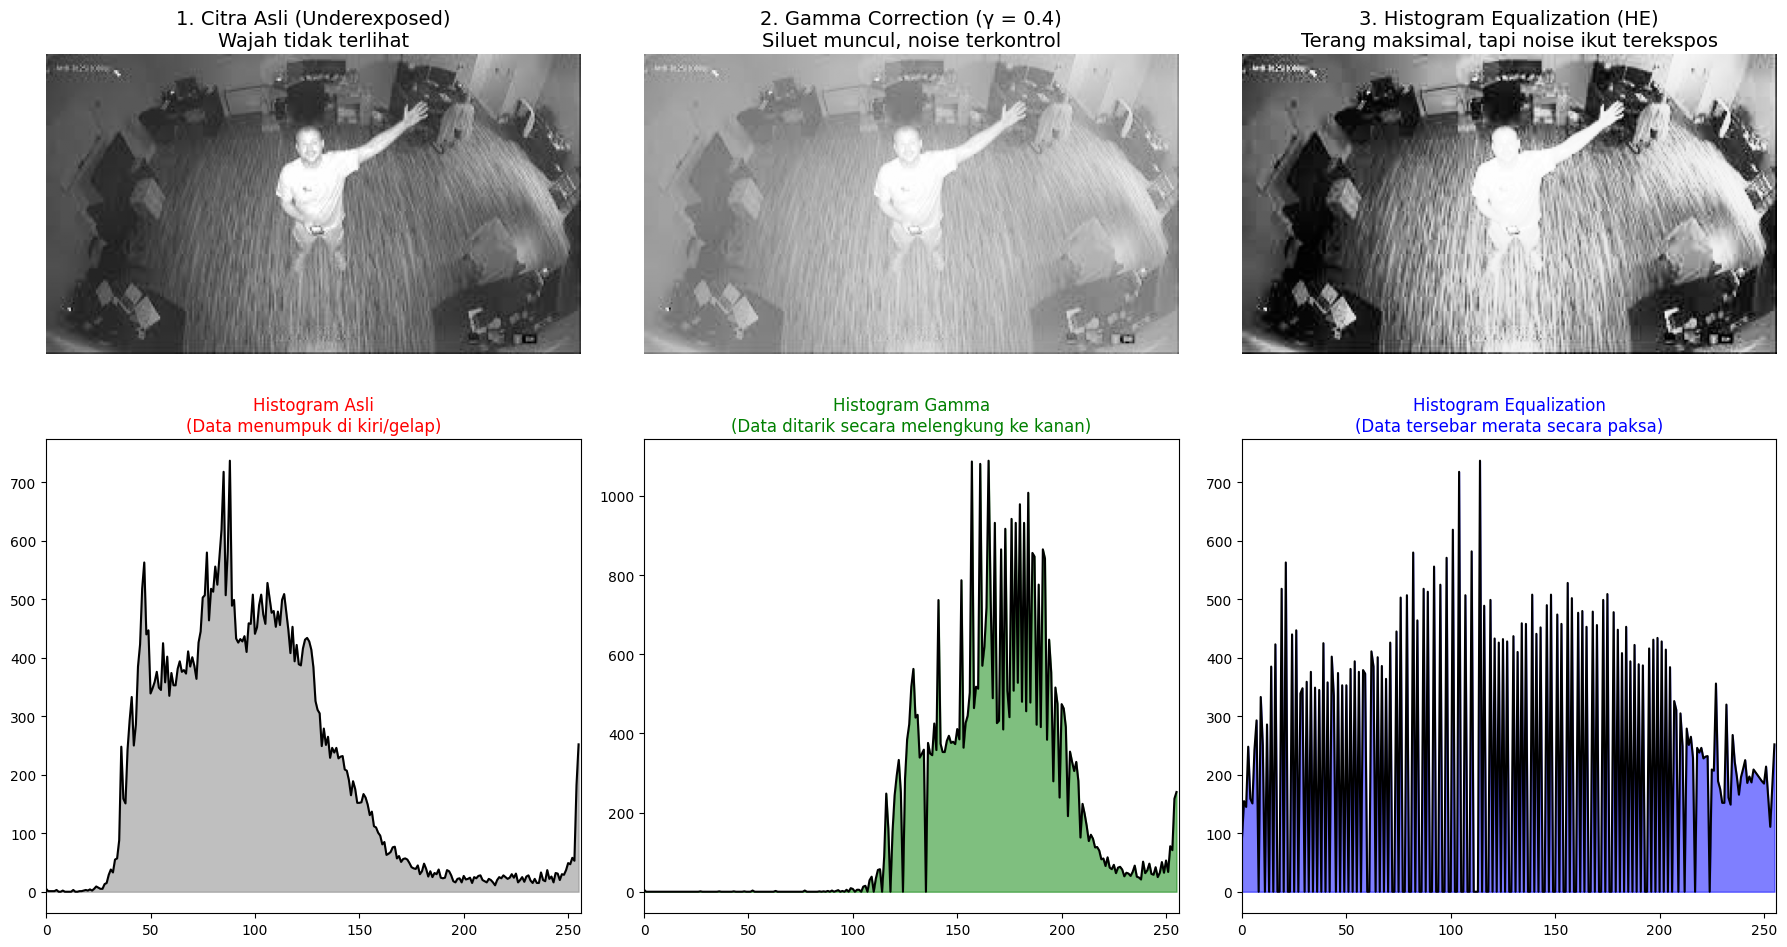

In [1]:
# ======================================================================
# DEMO PENGOLAHAN CITRA: POINT PROCESSING & HISTOGRAM
# Skenario Kasus: Forensik / Rekaman CCTV Gelap (Underexposed)
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA: MENGUNDUH / MEMBUAT CITRA CCTV GELAP
# ----------------------------------------------------------------------
def get_underexposed_image():
    # Pastikan nama file ini sama dengan yang Anda upload ke Colab
    filename = 'infrared.jpeg'
    # Cek apakah file ada di direktori Colab
    if os.path.exists(filename):
        print(f"Berhasil membaca gambar lokal: {filename}")
        # Membaca gambar dalam format Grayscale
        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
        return img

    else:
        # PLAN B: BUat image sintetis"
        print(f"Not found. Menggunakan Citra Sintetis...")

        # Buat background sangat gelap (nilai piksel 10-20, bukan 0)
        img = np.ones((500, 500), dtype=np.uint8) * 15

        # Gambar siluet "Pelaku" yang sedikit lebih terang (nilai piksel 30)
        cv2.circle(img, (250, 200), 60, 30, -1) # Kepala
        cv2.ellipse(img, (250, 450), (120, 200), 0, 0, 360, 30, -1) # Badan

        # Tambahkan sedikit "Noise Kamera CCTV Malam"
        noise = np.random.normal(0, 5, img.shape).astype(np.uint8)
        img = cv2.add(img, noise)
        return img

# Dapatkan citra asli (sangat gelap)
img_original = get_underexposed_image()

# ----------------------------------------------------------------------
# 2. METODE 1: GAMMA CORRECTION (Power-Law Transform)
# ----------------------------------------------------------------------
# Kita gunakan Gamma < 1 untuk mengangkat piksel gelap agar menjadi terang
gamma_value = 0.4

# Membuat Look-Up Table (LUT) untuk mempercepat komputasi per-piksel
# Rumus: s = c * r^gamma
lut = np.array([((i / 255.0) ** gamma_value) * 255
                for i in np.arange(0, 256)]).astype("uint8")

# Terapkan transformasi Gamma ke gambar
img_gamma = cv2.LUT(img_original, lut)

# ----------------------------------------------------------------------
# 3. METODE 2: HISTOGRAM EQUALIZATION (HE)
# ----------------------------------------------------------------------
# Menggunakan fungsi otomatis dari OpenCV untuk meratakan histogram
img_he = cv2.equalizeHist(img_original)

# ----------------------------------------------------------------------
# 4. FUNGSI BANTUAN UNTUK MENGHITUNG HISTOGRAM
# ----------------------------------------------------------------------
def calc_hist(image):
    # Menghitung sebaran piksel dari nilai 0 hingga 255
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    return hist

# ----------------------------------------------------------------------
# 5. VISUALISASI HASIL DENGAN MATPLOTLIB (Gambar & Histogramnya)
# ----------------------------------------------------------------------
plt.figure(figsize=(18, 10))

# --- KOLOM 1: CITRA ASLI ---
plt.subplot(2, 3, 1)
plt.title("1. Citra Asli (Underexposed)\nWajah tidak terlihat", fontsize=14)
plt.imshow(img_original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Histogram Asli\n(Data menumpuk di kiri/gelap)", color='red')
plt.plot(calc_hist(img_original), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(img_original).flatten(), color='gray', alpha=0.5)

# --- KOLOM 2: GAMMA CORRECTION ---
plt.subplot(2, 3, 2)
plt.title(f"2. Gamma Correction (γ = {gamma_value})\nSiluet muncul, noise terkontrol", fontsize=14)
plt.imshow(img_gamma, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Histogram Gamma\n(Data ditarik secara melengkung ke kanan)", color='green')
plt.plot(calc_hist(img_gamma), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(img_gamma).flatten(), color='green', alpha=0.5)

# --- KOLOM 3: HISTOGRAM EQUALIZATION ---
plt.subplot(2, 3, 3)
plt.title("3. Histogram Equalization (HE)\nTerang maksimal, tapi noise ikut terekspos", fontsize=14)
plt.imshow(img_he, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Histogram Equalization\n(Data tersebar merata secara paksa)", color='blue')
plt.plot(calc_hist(img_he), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(img_he).flatten(), color='blue', alpha=0.5)

plt.tight_layout()
plt.show()

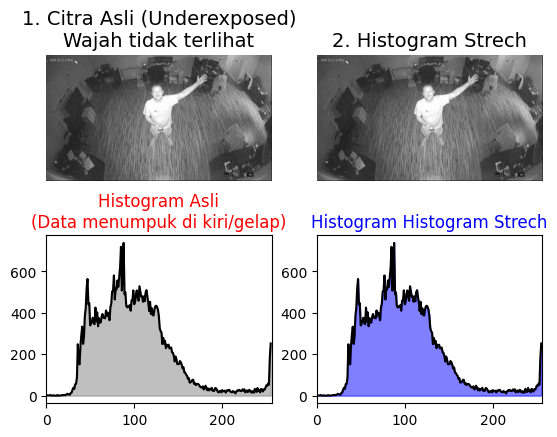

In [2]:
# Histogram streching
#1. find max
#2. find min
#3. Shift --> nilai min->0
#4. Scale --> nilai max -> 255

# 1. Find max
max_value = np.max(img_original)

#2. find min
min_value = np.min(img_original)

#3. Shift min into 0
img_stretch = img_original - min_value

#4. scale max into 255
img_stretch = img_stretch * round((255 / (max_value - min_value)))

# --- KOLOM 1: CITRA ASLI ---
plt.subplot(2, 2, 1)
plt.title("1. Citra Asli (Underexposed)\nWajah tidak terlihat", fontsize=14)
plt.imshow(img_original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Histogram Asli\n(Data menumpuk di kiri/gelap)", color='red')
plt.plot(calc_hist(img_original), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(img_original).flatten(), color='gray', alpha=0.5)

# --- KOLOM 2: Image Hist. Strech ---
plt.subplot(2, 2, 2)
plt.title("2. Histogram Strech", fontsize=14)
plt.imshow(img_stretch, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Histogram Histogram Strech", color='blue')
plt.plot(calc_hist(img_stretch), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(img_stretch).flatten(), color='blue', alpha=0.5)

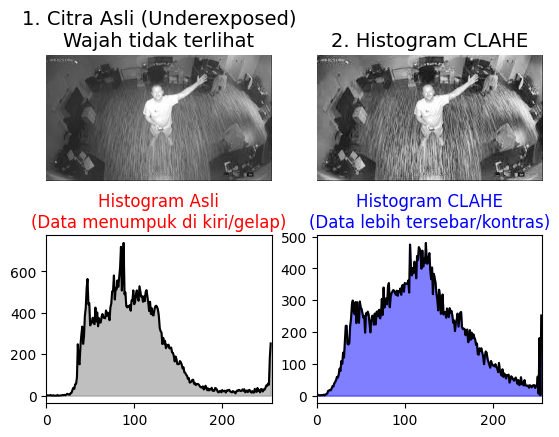

In [3]:
# Treapkan CLAHE (Contras Limited Adaptive Histogram Equalization)
# tentukan besar grid (8x8) dan clip limit
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(img_original)
# --- KOLOM 1: CITRA ASLI ---
plt.subplot(2, 2, 1)
plt.title("1. Citra Asli (Underexposed)\nWajah tidak terlihat", fontsize=14)
plt.imshow(img_original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Histogram Asli\n(Data menumpuk di kiri/gelap)", color='red')
plt.plot(calc_hist(img_original), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(img_original).flatten(), color='gray', alpha=0.5)

# --- KOLOM 2: Image CLAHE ---
plt.subplot(2, 2, 2)
plt.title("2. Histogram CLAHE", fontsize=14)
plt.imshow(clahe_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Histogram CLAHE\n(Data lebih tersebar/kontras)", color='blue')
plt.plot(calc_hist(clahe_img), color='black')
plt.xlim([0, 256])
plt.fill_between(range(256), calc_hist(clahe_img).flatten(), color='blue', alpha=0.5)
